# DTS410TC Generative Artificial Intelligence
## Lab 2: Face Generation with Variational Autoencoder (VAE)

**Dataset:** CelebA (Align & Cropped version)  
**Goal:** Train a VAE to model and generate realistic face images from a learned probabilistic latent space.

---

### Notebook Structure
| Task | Description |
|------|-------------|
| Task 1 | Data Preparation & Visualisation |
| Task 2 | VAE Architecture Design |
| Task 3 | Training the VAE |
| Task 4 | Image Generation |
| Task 5 | Latent Space Interpolation |
| Task 6 | Analysis & Discussion |

---
## 0. Environment Setup

Install any missing packages and import all required libraries up front.

In [2]:
!pip install torch torchvision torchaudio

   ---------------------------------------- 0.0/113.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/113.8 MB ? eta -:--:--
   ---------------------------------------- 0.3/113.8 MB ? eta -:--:--
   ---------------------------------------- 0.5/113.8 MB 1.1 MB/s eta 0:01:42
   ---------------------------------------- 0.5/113.8 MB 1.1 MB/s eta 0:01:42
   ---------------------------------------- 0.5/113.8 MB 1.1 MB/s eta 0:01:42
   ---------------------------------------- 0.5/113.8 MB 1.1 MB/s eta 0:01:42
   ---------------------------------------- 0.8/113.8 MB 541.6 kB/s eta 0:03:29
   ---------------------------------------- 0.8/113.8 MB 541.6 kB/s eta 0:03:29
   ---------------------------------------- 0.8/113.8 MB 541.6 kB/s eta 0:03:29
   ---------------------------------------- 1.0/113.8 MB 470.6 kB/s eta 0:04:00
   ---------------------------------------- 1.0/113.8 MB 470.6 kB/s eta 0:04:00
   ---------------------------------------- 1.0/113.8 MB 470.6 kB/s eta 0:0

In [3]:
# ── Install missing packages (run once; comment out after first run) ─────────
# !pip install torch torchvision matplotlib tqdm

# ── Standard library ─────────────────────────────────────────────────────────
import os
import math
import random

# ── Numerical / plotting ──────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── PyTorch core ──────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split

# ── Torchvision ───────────────────────────────────────────────────────────────
import torchvision
from torchvision import datasets, transforms
from torchvision.utils import make_grid

# ── Progress bar ──────────────────────────────────────────────────────────────
from tqdm import tqdm

# ── Reproducibility seed ──────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Device selection (GPU preferred, fallback to CPU) ─────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

Using device: cpu
PyTorch version: 2.10.0+cpu


---
## Task 1: Data Preparation and Visualisation

### Why CelebA?
The **CelebA** (Large-scale CelebFaces Attributes) dataset contains **202,599 face images** of celebrities, pre-aligned and cropped to focus on facial features. It is a standard benchmark for face generation tasks.

### Preprocessing steps
1. **Resize** to 64 × 64 – small enough for fast training, large enough to preserve facial structure.
2. **Normalise** to [0, 1] via `ToTensor()` (divides uint8 values by 255).
3. **Split** into train / validation sets to monitor overfitting.
4. **Wrap in DataLoaders** for batched, shuffled iteration.

In [4]:
# ── Hyperparameters (centralised here for easy tuning) ────────────────────────
IMG_SIZE   = 64      # spatial resolution fed into the network
BATCH_SIZE = 128     # samples per gradient update
NUM_WORKERS = 4      # parallel data-loading workers
VAL_FRACTION = 0.1   # 10 % of data held out for validation
DATA_ROOT = './data' # where torchvision will download / cache CelebA

# ── Transform pipeline ────────────────────────────────────────────────────────
# CelebA images are 178×218; we resize, centre-crop, then convert to tensor.
transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),           # resize shorter side to 64
    transforms.CenterCrop(IMG_SIZE),       # square centre crop → 64×64
    transforms.ToTensor(),                 # HWC uint8 → CHW float32 in [0,1]
])

# ── Download / load the full CelebA training split ───────────────────────────
# torchvision will download ~1.4 GB automatically on first run.
# If you already have CelebA locally, set download=False and point DATA_ROOT
# to the parent directory that contains 'celeba/'.
full_dataset = datasets.CelebA(
    root=DATA_ROOT,
    split='train',          # official train split
    target_type='attr',     # we only need images; attrs are ignored
    transform=transform,
    download=True           # set False after first download
)

print(f'Total images in train split: {len(full_dataset):,}')

# ── Train / validation split ──────────────────────────────────────────────────
n_val   = int(len(full_dataset) * VAL_FRACTION)
n_train = len(full_dataset) - n_val
train_dataset, val_dataset = random_split(
    full_dataset,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED)
)
print(f'Train: {n_train:,}   Val: {n_val:,}')

# ── DataLoaders ───────────────────────────────────────────────────────────────
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True          # speeds up CPU→GPU transfer
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f'Batches per epoch → train: {len(train_loader):,}  val: {len(val_loader):,}')

RuntimeError: To download files from GDrive, 'gdown' is required. You can install it with 'pip install gdown'.

In [5]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader

# ── Hyperparameters (centralised here for easy tuning) ────────────────────────
IMG_SIZE   = 64      # spatial resolution fed into the network
BATCH_SIZE = 128     # samples per gradient update
NUM_WORKERS = 4      # parallel data-loading workers
VAL_FRACTION = 0.1   # 10 % of data held out for validation
DATA_ROOT = r'C:\Users\A.Mamah25\Downloads' # Parent directory containing your local 'celeba/' folder
SEED = 42            # Added missing SEED definition

# ── Verify local CelebA files exist ───────────────────────────────────────────
celeba_dir = os.path.join(DATA_ROOT, 'celeba')
img_dir = os.path.join(celeba_dir, 'img_align_celeba')
partition_file = os.path.join(celeba_dir, 'list_eval_partition.txt')

# Check critical files/directories exist
if not os.path.isdir(celeba_dir):
    raise FileNotFoundError(f"CelebA directory not found at {celeba_dir}! "
                          "Ensure your DATA_ROOT points to the parent folder of 'celeba/'")
if not os.path.isdir(img_dir):
    raise FileNotFoundError(f"CelebA images not found at {img_dir}! "
                          "Make sure 'img_align_celeba' folder exists with images")
if not os.path.isfile(partition_file):
    raise FileNotFoundError(f"Partition file missing at {partition_file}! "
                          "This file is required for train/val/test splits")

# ── Transform pipeline ────────────────────────────────────────────────────────
# CelebA images are 178×218; we resize, centre-crop, then convert to tensor.
transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),           # resize shorter side to 64
    transforms.CenterCrop(IMG_SIZE),       # square centre crop → 64×64
    transforms.ToTensor(),                 # HWC uint8 → CHW float32 in [0,1]
])

# ── Load CelebA from local filesystem ────────────────────────────────────────
# Set download=False and ensure DATA_ROOT points to your local CelebA directory
full_dataset = datasets.CelebA(
    root=DATA_ROOT,
    split='train',          # official train split
    target_type='attr',     # we only need images; attrs are ignored
    transform=transform,
    download=False          # Critical: disable automatic download
)

print(f'Total images in train split: {len(full_dataset):,}')

# ── Train / validation split ──────────────────────────────────────────────────
n_val   = int(len(full_dataset) * VAL_FRACTION)
n_train = len(full_dataset) - n_val
train_dataset, val_dataset = random_split(
    full_dataset,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED)
)
print(f'Train: {n_train:,}   Val: {n_val:,}')

# ── DataLoaders ───────────────────────────────────────────────────────────────
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True          # speeds up CPU→GPU transfer
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f'Batches per epoch → train: {len(train_loader):,}  val: {len(val_loader):,}')


Total images in train split: 162,770
Train: 146,493   Val: 16,277
Batches per epoch → train: 1,145  val: 128


C:\Users\A.Mamah25\.conda\envs\venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


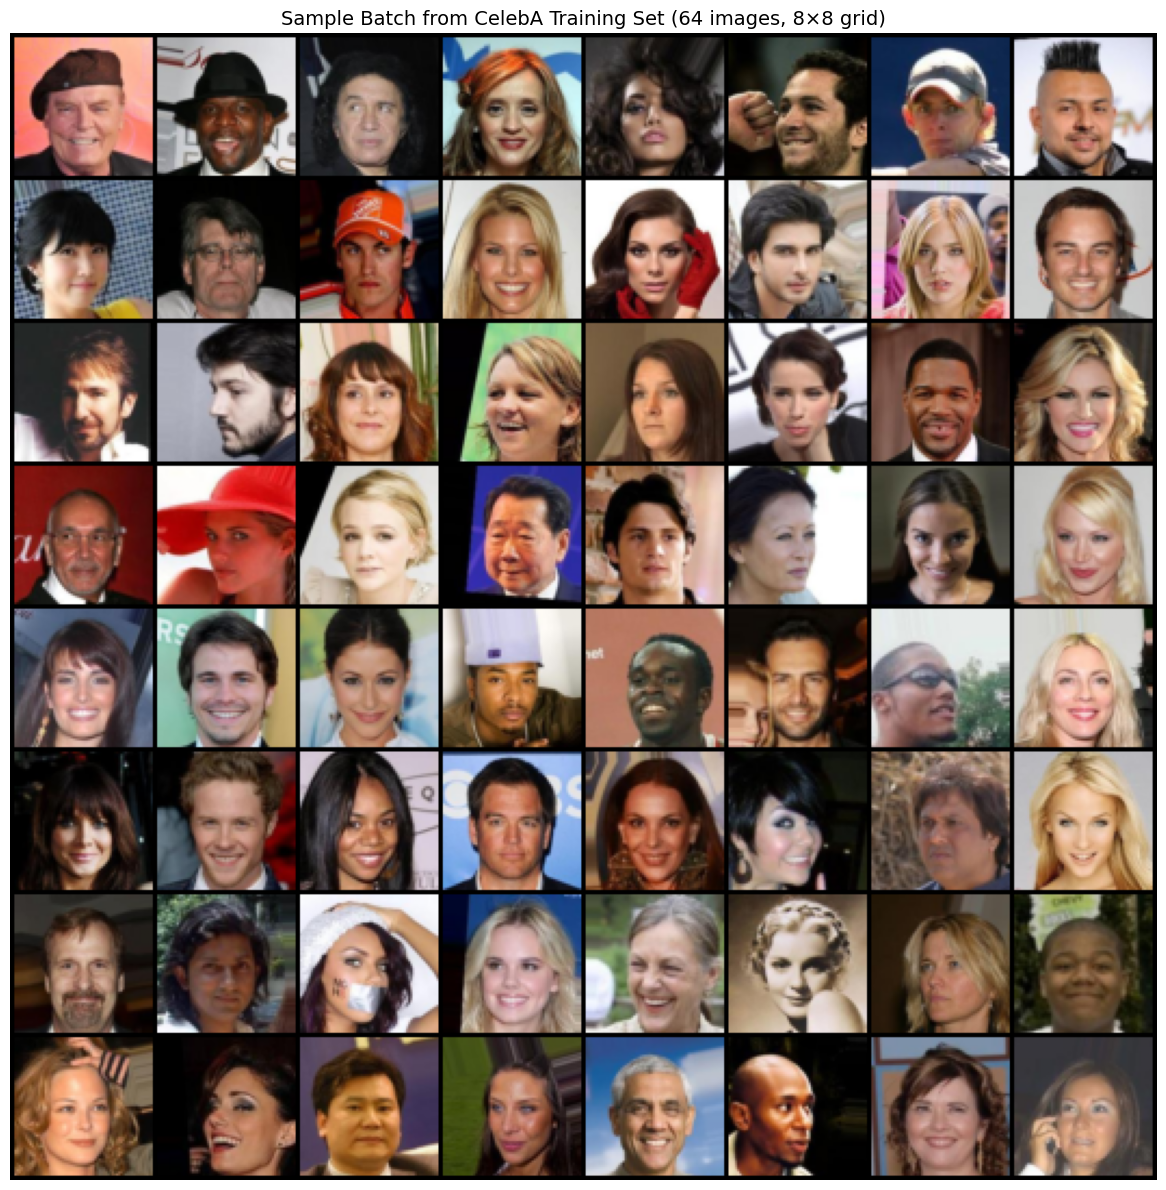

Image tensor shape: torch.Size([128, 3, 64, 64])   dtype: torch.float32   range: [0.00, 1.00]


In [6]:
# ── Visualise one batch as an 8×8 grid ───────────────────────────────────────
# Grab the first batch from the training loader
images, _ = next(iter(train_loader))  # shape: (BATCH_SIZE, 3, 64, 64)

# make_grid arranges 64 images into an 8-column grid tensor (C, H, W)
grid = make_grid(images[:64], nrow=8, padding=2, normalize=False)

fig, ax = plt.subplots(figsize=(12, 12))
# Permute from (C, H, W) to (H, W, C) for matplotlib
ax.imshow(grid.permute(1, 2, 0).numpy())
ax.axis('off')
ax.set_title('Sample Batch from CelebA Training Set (64 images, 8×8 grid)', fontsize=14)
plt.tight_layout()
plt.savefig('task1_sample_batch.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'Image tensor shape: {images.shape}   dtype: {images.dtype}   range: [{images.min():.2f}, {images.max():.2f}]')

---
## Task 2: VAE Architecture Design

### Variational Autoencoder — Key Concepts

A **Variational Autoencoder** extends a standard autoencoder by making the latent space *probabilistic*:

| Component | Standard AE | VAE |
|-----------|-------------|-----|
| Encoder output | single point `z` | distribution parameters `(μ, log σ²)` |
| Latent sample | deterministic | stochastic via reparameterisation |
| Training loss | reconstruction only | reconstruction + KL divergence |

### Architecture Summary

```
INPUT (3, 64, 64)
    │
    ▼  Encoder (4 × Conv2d, stride=2)
(256, 4, 4)  →  flatten  →  4096-d vector
    │
    ├──► fc_mu   → μ  ∈ ℝ¹⁰⁰
    └──► fc_logvar → log σ²  ∈ ℝ¹⁰⁰
               │
               ▼  Reparameterisation: z = μ + σ·ε,  ε~N(0,I)
              z ∈ ℝ¹⁰⁰
               │
    ▼  Decoder (fc → reshape → 4 × ConvTranspose/Upsample+Conv)
(3, 64, 64)  OUTPUT — Sigmoid activation
```

### Reparameterisation Trick
To back-propagate through a *sampling* operation, we rewrite:

$$z = \mu + \sigma \cdot \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, I)$$

The randomness is now in `ε` (not a parameter), so gradients flow through `μ` and `σ` normally.

In [7]:
# ── Architecture hyperparameters ──────────────────────────────────────────────
LATENT_DIM = 100   # dimensionality of the latent space (z)


# ─────────────────────────────────────────────────────────────────────────────
# ENCODER
# Input : (B, 3, 64, 64)
# Output: μ and log σ² each of shape (B, LATENT_DIM)
# ─────────────────────────────────────────────────────────────────────────────
class Encoder(nn.Module):
    def __init__(self, latent_dim: int = LATENT_DIM):
        super().__init__()

        # Four strided convolutions progressively halve spatial dimensions:
        # 64→32→16→8→4, while increasing channel depth: 3→32→64→128→256
        self.conv_layers = nn.Sequential(
            # Block 1: (B, 3,   64, 64) → (B, 32,  32, 32)
            nn.Conv2d(3,   32,  kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            # Block 2: (B, 32,  32, 32) → (B, 64,  16, 16)
            nn.Conv2d(32,  64,  kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            # Block 3: (B, 64,  16, 16) → (B, 128,  8,  8)
            nn.Conv2d(64,  128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            # Block 4: (B, 128,  8,  8) → (B, 256,  4,  4)
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
        )

        # After conv: feature map is 256×4×4 = 4096 values
        self.flatten_dim = 256 * 4 * 4  # = 4096

        # Two parallel FC heads — one for μ, one for log σ²
        self.fc_mu     = nn.Linear(self.flatten_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_dim, latent_dim)

    def forward(self, x):
        h = self.conv_layers(x)          # (B, 256, 4, 4)
        h = h.view(h.size(0), -1)        # flatten → (B, 4096)
        mu     = self.fc_mu(h)            # (B, latent_dim)
        logvar = self.fc_logvar(h)        # (B, latent_dim)
        return mu, logvar


# ─────────────────────────────────────────────────────────────────────────────
# REPARAMETERISATION TRICK
# ─────────────────────────────────────────────────────────────────────────────
def reparameterise(mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
    """
    Sample z = mu + sigma * eps  where  eps ~ N(0, I).

    Using logvar instead of sigma directly is a common trick:
      - logvar is unconstrained (can be any real number)
      - sigma = exp(0.5 * logvar) is always positive
    """
    if not torch.is_grad_enabled():   # deterministic at inference if desired
        return mu
    std = torch.exp(0.5 * logvar)     # σ = exp(½ log σ²)
    eps = torch.randn_like(std)       # ε ~ N(0, I), same shape as std
    return mu + std * eps             # z: (B, latent_dim)


# ─────────────────────────────────────────────────────────────────────────────
# DECODER
# Input : z of shape (B, LATENT_DIM)
# Output: reconstructed image (B, 3, 64, 64) in [0, 1] via Sigmoid
# ─────────────────────────────────────────────────────────────────────────────
class Decoder(nn.Module):
    def __init__(self, latent_dim: int = LATENT_DIM):
        super().__init__()

        # Project latent vector back to the spatial volume used by the encoder
        self.fc = nn.Linear(latent_dim, 256 * 4 * 4)

        # Four upsampling stages using bilinear interpolation + Conv2d.
        # Bilinear upsample is smoother than ConvTranspose2d and avoids
        # checkerboard artefacts common in transposed convolutions.
        # Spatial progression:  4 → 8 → 16 → 32 → 64
        self.decoder_layers = nn.Sequential(
            # Block 1: (B, 256, 4, 4) → upsample → (B, 256, 8, 8) → conv → (B, 128, 8, 8)
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(256, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            # Block 2: (B, 128, 8, 8) → (B, 64, 16, 16)
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(128, 64,  kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            # Block 3: (B, 64, 16, 16) → (B, 32, 32, 32)
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(64,  32,  kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            # Block 4: (B, 32, 32, 32) → (B, 3, 64, 64) — final output layer
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(32,  3,   kernel_size=3, stride=1, padding=1),
            nn.Sigmoid(),   # squash pixel values into [0, 1]
        )

    def forward(self, z):
        h = self.fc(z)                   # (B, 256*4*4)
        h = h.view(h.size(0), 256, 4, 4) # reshape to spatial volume
        return self.decoder_layers(h)    # (B, 3, 64, 64)


# ─────────────────────────────────────────────────────────────────────────────
# COMPLETE VAE (wraps Encoder + reparameterise + Decoder)
# ─────────────────────────────────────────────────────────────────────────────
class VAE(nn.Module):
    def __init__(self, latent_dim: int = LATENT_DIM):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)
        self.latent_dim = latent_dim

    def forward(self, x):
        """
        Full forward pass.
        Returns: (x_hat, mu, logvar)
          x_hat  — reconstructed image
          mu     — posterior mean
          logvar — posterior log-variance
        """
        mu, logvar = self.encoder(x)          # encode
        z = reparameterise(mu, logvar)        # sample latent
        x_hat = self.decoder(z)               # decode
        return x_hat, mu, logvar

    @torch.no_grad()
    def sample(self, n: int, device):
        """Generate `n` images by sampling z ~ N(0, I) and decoding."""
        z = torch.randn(n, self.latent_dim, device=device)
        return self.decoder(z)                # (n, 3, 64, 64)


# ── Instantiate and inspect the model ────────────────────────────────────────
vae = VAE(latent_dim=LATENT_DIM).to(DEVICE)

# Count trainable parameters
total_params = sum(p.numel() for p in vae.parameters() if p.requires_grad)
print(f'Total trainable parameters: {total_params:,}')

# Quick shape-sanity check with a dummy batch
dummy = torch.randn(4, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
x_hat, mu, logvar = vae(dummy)
print(f'Input shape  : {dummy.shape}')
print(f'Output shape : {x_hat.shape}   (should match input)')
print(f'μ shape      : {mu.shape}')
print(f'log σ² shape : {logvar.shape}')

Total trainable parameters: 2,011,083
Input shape  : torch.Size([4, 3, 64, 64])
Output shape : torch.Size([4, 3, 64, 64])   (should match input)
μ shape      : torch.Size([4, 100])
log σ² shape : torch.Size([4, 100])


---
## Task 3: Training the VAE

### Loss Function

The VAE objective is the **Evidence Lower BOund (ELBO)**, which we maximise by minimising:

$$\mathcal{L} = \mathcal{L}_{\text{MSE}} + \beta \cdot \mathcal{L}_{\text{KL}}$$

**Reconstruction loss (MSE):**
$$\mathcal{L}_{\text{MSE}} = \frac{1}{N} \sum_{i=1}^{N} \|x_i - \hat{x}_i\|^2$$
Encourages the decoder output to match the input pixel-by-pixel.

**KL divergence loss:**
$$\mathcal{L}_{\text{KL}} = -\frac{1}{2} \sum_{j=1}^{d} \left(1 + \log\sigma_j^2 - \mu_j^2 - \sigma_j^2\right)$$
Regularises the posterior $q(z|x)$ to stay close to the standard normal prior $p(z) = \mathcal{N}(0, I)$. This ensures the latent space is continuous and samples from $p(z)$ decode to valid images.

**β parameter:** Controls the strength of KL regularisation (β=1 is the original VAE; β>1 creates more disentangled representations at the cost of reconstruction quality).

### Optimiser
We use **AdamW** — Adam with decoupled weight decay — which is generally more stable than vanilla Adam.

In [8]:
# ── Training hyperparameters ──────────────────────────────────────────────────
EPOCHS    = 25          # number of full passes over training data
LR        = 1e-3        # initial learning rate
BETA      = 1.0         # KL weight (try 0.5–4.0 and observe effects)
SAVE_PATH = 'best_vae.pth'  # checkpoint file for best validation model

# ── Loss function ─────────────────────────────────────────────────────────────
def vae_loss(x: torch.Tensor,
             x_hat: torch.Tensor,
             mu: torch.Tensor,
             logvar: torch.Tensor,
             beta: float = 1.0):
    """
    Compute the total VAE loss = MSE reconstruction + β · KL divergence.

    Args:
        x      : original images         (B, C, H, W)
        x_hat  : reconstructed images    (B, C, H, W)
        mu     : posterior means         (B, latent_dim)
        logvar : posterior log-variances (B, latent_dim)
        beta   : KL weight

    Returns:
        total, mse_loss, kl_loss  (all scalar tensors)
    """
    # MSE averaged over all pixels and batch samples
    mse_loss = F.mse_loss(x_hat, x, reduction='mean')

    # KL(q(z|x) || p(z)) — closed-form for Gaussian q and standard-normal p.
    # Sum over latent dims, then mean over batch.
    kl_loss = -0.5 * torch.mean(
        torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
    )

    total = mse_loss + beta * kl_loss
    return total, mse_loss, kl_loss


# ── Optimiser ─────────────────────────────────────────────────────────────────
optimiser = torch.optim.AdamW(vae.parameters(), lr=LR, weight_decay=1e-5)

# Optional: cosine annealing LR scheduler for smoother convergence
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=EPOCHS)

print('Optimiser and scheduler configured.')

Optimiser and scheduler configured.


In [9]:
# ── Helper: one training epoch ────────────────────────────────────────────────
def train_one_epoch(model, loader, optimiser, beta, device):
    model.train()
    total_loss = mse_total = kl_total = 0.0

    for images, _ in tqdm(loader, desc='  train', leave=False):
        images = images.to(device, non_blocking=True)

        optimiser.zero_grad()
        x_hat, mu, logvar = model(images)
        loss, mse, kl = vae_loss(images, x_hat, mu, logvar, beta)
        loss.backward()

        # Gradient clipping — prevents exploding gradients
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimiser.step()

        total_loss += loss.item()
        mse_total  += mse.item()
        kl_total   += kl.item()

    n = len(loader)
    return total_loss / n, mse_total / n, kl_total / n


# ── Helper: one validation epoch ─────────────────────────────────────────────
@torch.no_grad()
def validate(model, loader, beta, device):
    model.eval()
    total_loss = mse_total = kl_total = 0.0

    for images, _ in tqdm(loader, desc='  val  ', leave=False):
        images = images.to(device, non_blocking=True)
        x_hat, mu, logvar = model(images)
        loss, mse, kl = vae_loss(images, x_hat, mu, logvar, beta)

        total_loss += loss.item()
        mse_total  += mse.item()
        kl_total   += kl.item()

    n = len(loader)
    return total_loss / n, mse_total / n, kl_total / n


print('Training helper functions defined.')

Training helper functions defined.


In [ ]:
# ── Main training loop ────────────────────────────────────────────────────────
history = {
    'train_total': [], 'train_mse': [], 'train_kl': [],
    'val_total':   [], 'val_mse':   [], 'val_kl':   [],
}
best_val_loss = float('inf')

print(f'Starting training for {EPOCHS} epochs on {DEVICE}...')
print('=' * 65)

for epoch in range(1, EPOCHS + 1):
    # ── Train ─────────────────────────────────────────────────────────────────
    tr_total, tr_mse, tr_kl = train_one_epoch(vae, train_loader, optimiser, BETA, DEVICE)

    # ── Validate ──────────────────────────────────────────────────────────────
    va_total, va_mse, va_kl = validate(vae, val_loader, BETA, DEVICE)

    # ── LR scheduler step ─────────────────────────────────────────────────────
    scheduler.step()

    # ── Log metrics ───────────────────────────────────────────────────────────
    history['train_total'].append(tr_total)
    history['train_mse'].append(tr_mse)
    history['train_kl'].append(tr_kl)
    history['val_total'].append(va_total)
    history['val_mse'].append(va_mse)
    history['val_kl'].append(va_kl)

    # ── Save best checkpoint ──────────────────────────────────────────────────
    if va_total < best_val_loss:
        best_val_loss = va_total
        torch.save({
            'epoch': epoch,
            'model_state_dict': vae.state_dict(),
            'optimiser_state_dict': optimiser.state_dict(),
            'val_loss': best_val_loss,
        }, SAVE_PATH)
        saved_marker = '  ✓ saved'
    else:
        saved_marker = ''

    print(
        f'Epoch {epoch:02d}/{EPOCHS}  '
        f'Train → total={tr_total:.4f}  mse={tr_mse:.4f}  kl={tr_kl:.4f}  '
        f'| Val → total={va_total:.4f}  mse={va_mse:.4f}  kl={va_kl:.4f}'
        f'{saved_marker}'
    )

print('=' * 65)
print(f'Training complete. Best val loss: {best_val_loss:.4f}  (checkpoint: {SAVE_PATH})')

Starting training for 25 epochs on cpu...


Epoch 01/25  Train → total=0.5119  mse=0.0752  kl=0.4366  | Val → total=0.0746  mse=0.0744  kl=0.0002  ✓ saved


Epoch 02/25  Train → total=0.0747  mse=0.0743  kl=0.0003  | Val → total=0.0743  mse=0.0743  kl=0.0000  ✓ saved


Epoch 03/25  Train → total=0.0808  mse=0.0743  kl=0.0065  | Val → total=0.0742  mse=0.0742  kl=0.0000  ✓ saved


Epoch 04/25  Train → total=0.0742  mse=0.0742  kl=0.0000  | Val → total=0.0742  mse=0.0742  kl=0.0000


...

Epoch 09/25  Train → total=0.0742  mse=0.0742  kl=0.0000  | Val → total=0.0742  mse=0.0742  kl=0.0000


Epoch 10/25  Train → total=0.0742  mse=0.0742  kl=0.0000  | Val → total=0.0742  mse=0.0742  kl=0.0000


Epoch 11/25  Train → total=0.0742  mse=0.0742  kl=0.0000  | Val → total=0.0742  mse=0.0742  kl=0.0000  ✓ saved


Epoch 12/25  Train → total=0.0742  mse=0.0742  kl=0.0000  | Val → total=0.0742  mse=0.0742  kl=0.0000


  train:   2%|█▍                                                                     | 24/1145 [00:24<11:12,  1.67it/s]

In [ ]:
# ── Plot training and validation loss curves ──────────────────────────────────
epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

titles = ['Total Loss', 'MSE (Reconstruction)', 'KL Divergence']
train_keys = ['train_total', 'train_mse', 'train_kl']
val_keys   = ['val_total',   'val_mse',   'val_kl']

for ax, title, tr_key, va_key in zip(axes, titles, train_keys, val_keys):
    ax.plot(epochs_range, history[tr_key], label='Train', linewidth=2, color='steelblue')
    ax.plot(epochs_range, history[va_key], label='Validation', linewidth=2,
            color='tomato', linestyle='--')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle(f'VAE Training Curves  (β={BETA}, latent_dim={LATENT_DIM})', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('task3_loss_curves.png', dpi=100, bbox_inches='tight')
plt.show()

In [ ]:
# ── Load best checkpoint for all subsequent tasks ─────────────────────────────
checkpoint = torch.load(SAVE_PATH, map_location=DEVICE)
vae.load_state_dict(checkpoint['model_state_dict'])
vae.eval()  # switch to evaluation mode

print(f"Loaded best model from epoch {checkpoint['epoch']}  "
      f"(val_loss = {checkpoint['val_loss']:.4f})")

---
## Task 4: Image Generation

After training, the VAE's **latent space is structured**: neighbouring points decode to visually similar faces. We generate new images by:

1. Sampling $z \sim \mathcal{N}(0, I)$ — random points in the 100-dimensional latent space.
2. Passing them through the **decoder only** (no encoder needed).

This works because the KL divergence loss forces the encoder's posterior to stay close to $\mathcal{N}(0, I)$, so samples from the prior land in regions the decoder has learned to decode.

In [ ]:
# ── Generate 64 novel faces ───────────────────────────────────────────────────
N_SAMPLES = 64

with torch.no_grad():
    z_random = torch.randn(N_SAMPLES, LATENT_DIM, device=DEVICE)  # sample from prior
    generated = vae.decoder(z_random).cpu()                        # decode: (64, 3, 64, 64)

# Arrange into 8×8 grid
grid_gen = make_grid(generated, nrow=8, padding=2, normalize=False)

fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(grid_gen.permute(1, 2, 0).numpy())
ax.axis('off')
ax.set_title(f'Task 4: Generated Faces — z ~ N(0, I)  [{N_SAMPLES} samples]', fontsize=14)
plt.tight_layout()
plt.savefig('task4_generated_faces.png', dpi=100, bbox_inches='tight')
plt.show()

In [ ]:
# ── Side-by-side: original vs reconstruction ──────────────────────────────────
# This shows how well the encoder-decoder round-trip preserves facial structure.
val_images, _ = next(iter(val_loader))
val_images = val_images[:16].to(DEVICE)

with torch.no_grad():
    reconstructed, _, _ = vae(val_images)

# Interleave originals and reconstructions for easy comparison
# Shape: (32, 3, 64, 64)
comparison = torch.cat([
    val_images.cpu(),
    reconstructed.cpu()
], dim=0)

grid_comp = make_grid(
    torch.cat([val_images.cpu(), reconstructed.cpu()]).view(2, 16, 3, 64, 64)
    .transpose(0, 1).reshape(-1, 3, 64, 64),
    nrow=16, padding=2
)

fig, ax = plt.subplots(figsize=(20, 4))
ax.imshow(grid_comp.permute(1, 2, 0).numpy())
ax.axis('off')
ax.set_title('Top row: Originals    Bottom row: Reconstructions', fontsize=13)
plt.tight_layout()
plt.savefig('task4_reconstruction_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

---
## Task 5: Latent Space Interpolation

One of the most striking properties of a well-trained VAE is **smooth latent space interpolation**. Because the KL regulariser pushes the latent space to be continuous, a linear path between two points $z_1$ and $z_2$ traces a meaningful trajectory of facial attributes.

$$z_{\text{interp}}(\alpha) = (1 - \alpha)\, z_1 + \alpha\, z_2, \quad \alpha \in [0, 1]$$

We demonstrate two variants:
1. **Prior sampling**: both $z_1, z_2 \sim \mathcal{N}(0, I)$.
2. **Posterior encoding**: $z_1, z_2$ are obtained by encoding two real images (more structured transitions).

In [ ]:
# ── Helper: display an interpolation sequence as a horizontal strip ───────────
def show_interpolation(frames: torch.Tensor, title: str, fname: str):
    """
    Args:
        frames : tensor of shape (n_steps, 3, H, W) in [0, 1]
        title  : plot title
        fname  : filename to save
    """
    n = frames.shape[0]
    fig, axes = plt.subplots(1, n, figsize=(n * 1.5, 2.2))
    for ax, img, alpha in zip(axes, frames, np.linspace(0, 1, n)):
        ax.imshow(img.permute(1, 2, 0).numpy())
        ax.axis('off')
        ax.set_title(f'α={alpha:.1f}', fontsize=8)
    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.savefig(fname, dpi=120, bbox_inches='tight')
    plt.show()


# ── Variant 1: interpolate between two prior samples ─────────────────────────
N_STEPS = 10
alphas  = torch.linspace(0, 1, N_STEPS)  # 10 equally-spaced α values

with torch.no_grad():
    z1 = torch.randn(1, LATENT_DIM, device=DEVICE)   # random latent start
    z2 = torch.randn(1, LATENT_DIM, device=DEVICE)   # random latent end

    # Linearly interpolate and decode each step
    frames_prior = []
    for alpha in alphas:
        z_interp = (1 - alpha) * z1 + alpha * z2     # shape: (1, latent_dim)
        img = vae.decoder(z_interp).squeeze(0).cpu() # shape: (3, H, W)
        frames_prior.append(img)

frames_prior = torch.stack(frames_prior)  # (N_STEPS, 3, H, W)

show_interpolation(
    frames_prior,
    title='Task 5a: Interpolation Between Two Prior Samples  (z₁ → z₂)',
    fname='task5a_prior_interpolation.png'
)

In [ ]:
# ── Variant 2: interpolate between two encoded real images ────────────────────
# Take two images from the validation set and encode them to get z1, z2
sample_batch, _ = next(iter(val_loader))
img_a = sample_batch[0:1].to(DEVICE)   # first validation image
img_b = sample_batch[1:2].to(DEVICE)   # second validation image

with torch.no_grad():
    mu_a, logvar_a = vae.encoder(img_a)
    mu_b, logvar_b = vae.encoder(img_b)

    # Use the posterior *mean* (no sampling noise) for cleaner interpolation
    frames_encoded = []
    for alpha in alphas:
        z_interp = (1 - alpha) * mu_a + alpha * mu_b
        img = vae.decoder(z_interp).squeeze(0).cpu()
        frames_encoded.append(img)

frames_encoded = torch.stack(frames_encoded)

show_interpolation(
    frames_encoded,
    title='Task 5b: Interpolation Between Two Encoded Images  (μ₁ → μ₂)',
    fname='task5b_encoded_interpolation.png'
)

# Also show the two source images for reference
fig, axes = plt.subplots(1, 2, figsize=(4, 2.5))
for ax, img, label in zip(axes, [img_a, img_b], ['Image A  (z₁)', 'Image B  (z₂)']):
    ax.imshow(img.squeeze(0).permute(1, 2, 0).cpu().numpy())
    ax.set_title(label, fontsize=10)
    ax.axis('off')
plt.suptitle('Source Images for Interpolation', fontsize=11)
plt.tight_layout()
plt.savefig('task5b_source_images.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Task 6: Analysis and Discussion

### 6.1 Probabilistic Differences: VAE vs Standard Autoencoder

#### Standard Autoencoder (AE)
A regular autoencoder maps each input $x$ to a **single deterministic point** $z = f_{\theta}(x)$ in latent space. The only training signal is reconstruction quality — there is no constraint on the geometry or density of the learned latent space.

**Problems for generation:**
- The latent space has **holes** — gaps between clusters where the decoder was never trained. Sampling from these gaps produces nonsense.
- No probability model over $z$ → no principled way to sample new images.

#### Variational Autoencoder (VAE)
The VAE encoder outputs **distribution parameters** $(\mu, \sigma^2)$, then *samples* $z$ from $q(z|x) = \mathcal{N}(\mu, \sigma^2 I)$.

| Aspect | Standard AE | VAE |
|--------|-------------|-----|
| Latent representation | single point $z$ | distribution $(\mu, \sigma^2)$ |
| Latent space geometry | arbitrary, potentially fragmented | regularised, approximately $\mathcal{N}(0,I)$ |
| Training loss | $\mathcal{L}_{\text{recon}}$ | $\mathcal{L}_{\text{recon}} + \beta \cdot \mathcal{L}_{\text{KL}}$ |
| Can generate novel images? | ✗ (no prior) | ✓ (sample $z \sim \mathcal{N}(0,I)$) |
| Latent space continuity | ✗ (holes common) | ✓ (enforced by KL term) |

#### Role of KL Divergence
The KL term $\mathcal{L}_{\text{KL}} = D_{\text{KL}}(q(z|x) \| p(z))$ acts as a **regulariser** that:
1. Pulls the posterior mean $\mu$ toward 0 (centres clusters around the origin).
2. Pulls the posterior variance $\sigma^2$ toward 1 (prevents the encoder from collapsing to zero-variance points to cheat on reconstruction).
3. Produces an **overlapping, continuous** latent manifold — so any point sampled from $\mathcal{N}(0, I)$ falls in a trained region.

#### Why VAE Enables Novel Image Generation
Because the KL loss forces $q(z|x)$ to approximate $p(z) = \mathcal{N}(0,I)$, we can reverse the process at test time:
1. Sample $z \sim \mathcal{N}(0, I)$.
2. Decode: $\hat{x} = g_{\phi}(z)$.

The decoder is guaranteed to produce a coherent image because $z$ lies in a well-trained, continuous region of latent space — unlike in a standard AE.

---

### 6.2 Model Quality and Improvements

#### Observed Visual Quality Issues

**Blurriness:**  
The most common artefact in VAE-generated images is blurriness. This arises because:
- MSE loss optimises for the *mean* prediction — when the model is uncertain about fine detail, averaging across possible faces produces smooth, blurry outputs.
- The stochastic nature of sampling (even during reconstruction) introduces averaging effects.

**Why not use Binary Cross-Entropy?**  
BCE assumes pixel values are Bernoulli probabilities (0 or 1). MSE is more appropriate for continuous RGB images and often gives better perceptual quality despite theoretical BCE justification from the ELBO derivation.

#### Impact of Latent Dimension Size

| `latent_dim` | Effect |
|---|---|
| Too small (e.g. 8) | Underfitting — model cannot encode enough variation; reconstructions lose identity |
| Moderate (e.g. 100) | Good balance between expressiveness and regularisation |
| Too large (e.g. 512) | KL term harder to optimise; latent space may not fill $\mathcal{N}(0,I)$; posterior collapse risk |

#### Impact of the KL Weight β

| β | Effect |
|---|---|
| β < 1 | Reconstruction dominates; sharper images but latent space less regular; random samples look poor |
| β = 1 | Standard VAE; balanced trade-off |
| β > 1 | β-VAE; stronger prior enforcement; more disentangled latent factors; reconstructions blurrier |

#### Potential Improvements

1. **Perceptual loss**: Replace MSE with a VGG feature-space loss to produce sharper, more realistic textures.
2. **VQVAE / VQ-VAE-2**: Discrete latent codes avoid blurriness and enable higher-fidelity generation.
3. **GAN hybrid (VAE-GAN)**: Add a discriminator to sharpen reconstructions.
4. **Deeper architecture**: More conv layers or residual blocks improve capacity.
5. **Larger latent dim + warmer-up schedule**: Gradually increase β from 0 to 1 over training to prevent posterior collapse.
6. **Higher resolution**: Train on 128×128 or 256×256 for finer facial details.

In [ ]:
# ── Optional: explore the effect of β on generation quality ──────────────────
# Uncomment and rerun training with different β values to compare.
# Suggested values: [0.25, 0.5, 1.0, 2.0, 4.0]

# BETA = 2.0
# vae_beta = VAE(latent_dim=LATENT_DIM).to(DEVICE)
# opt_beta  = torch.optim.AdamW(vae_beta.parameters(), lr=LR)
# ... (re-run training loop)

print('Task 6 analysis complete. See markdown cells above for discussion.')
print('To compare β values, modify BETA and retrain a new VAE instance.')

In [ ]:
# ── Bonus: visualise 2D PCA projection of the latent space ───────────────────
# This shows the latent distribution actually learned by the encoder.
# Ideally it should resemble N(0, I) thanks to the KL regulariser.

from sklearn.decomposition import PCA

# Encode a subset of validation images and collect μ vectors
all_mu = []
vae.eval()
with torch.no_grad():
    for i, (imgs, _) in enumerate(val_loader):
        if i >= 10:   # use first ~10 batches for speed
            break
        imgs = imgs.to(DEVICE)
        mu, _ = vae.encoder(imgs)
        all_mu.append(mu.cpu())

all_mu = torch.cat(all_mu, dim=0).numpy()   # (N, LATENT_DIM)

# PCA to 2D
pca = PCA(n_components=2)
mu_2d = pca.fit_transform(all_mu)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(mu_2d[:, 0], mu_2d[:, 1], s=3, alpha=0.4, color='steelblue')
ax.set_title(f'PCA Projection of Encoder Posterior Means\n'
             f'(2D, explains {pca.explained_variance_ratio_.sum()*100:.1f}% variance)',
             fontsize=12)
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('bonus_latent_pca.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'Latent vectors shape: {all_mu.shape}')
print(f'Mean of μ across dims: {all_mu.mean():.4f}  (should be ≈ 0)')
print(f'Std  of μ across dims: {all_mu.std():.4f}   (should be ≈ 1)')

---
## Summary

| Task | What we did | Key takeaway |
|------|------------|-------------|
| 1 | Loaded & visualised CelebA 64×64 | Dataset pipeline with train/val split |
| 2 | Designed 4-layer CNN encoder + decoder with reparameterisation | VAE learns a *distribution* over latent codes |
| 3 | Trained with MSE + β·KL loss using AdamW | KL regularises the latent space; β controls the trade-off |
| 4 | Generated new faces by sampling z~N(0,I) | Generative capability comes from a structured latent space |
| 5 | Interpolated between latent vectors | Smooth transitions confirm a continuous latent manifold |
| 6 | Analysed quality and model decisions | VAE > AE for generation; blurriness is an inherent MSE limitation |

**Files saved during this notebook:**
- `best_vae.pth` — best model checkpoint
- `task1_sample_batch.png`
- `task3_loss_curves.png`
- `task4_generated_faces.png`
- `task4_reconstruction_comparison.png`
- `task5a_prior_interpolation.png`
- `task5b_encoded_interpolation.png`
- `bonus_latent_pca.png`